In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

import matplotlib.pyplot as plt

@jax.jit
def complex_permittivity_ice(T, nu):
    """
    Computes the complex dielectric permittivity of pure ice (Mätzler 2006).
    
    Args:
        T: Physical temperature of the ice in Kelvin (valid 180 K to 273.15 K).
        nu: Frequency in GHz (valid 1 GHz to 1000 GHz).
        
    Returns:
        epsilon: Complex permittivity (epsilon' + i * epsilon'').
    """
    # -------------------------------------------------------------
    # 1. Real Part (epsilon_prime)
    # -------------------------------------------------------------
    # Linear temperature dependence (Eq. 5.30)
    epsilon_prime = 3.1884 + 9.1e-4 * (T - 273.0)
    
    # -------------------------------------------------------------
    # 2. Imaginary Part (epsilon_double_prime)
    # -------------------------------------------------------------
    # Calculate alpha term (low-frequency Debye relaxation tail)
    theta = (300.0 / T) - 1.0
    alpha = (0.00504 + 0.0062 * theta) * jnp.exp(-22.1 * theta)
    
    # Calculate beta_M (Mishima cold ice baseline term)
    B1 = 0.0207
    b = 335.0
    B2 = 1.16e-11
    
    exp_bT = jnp.exp(b / T)
    beta_M = (B1 / T) * (exp_bT / (exp_bT - 1.0)**2) + B2 * (nu**2)
    
    # Calculate delta_beta (Empirical correction for warmer temperatures)
    delta_beta = jnp.exp(-9.963 + 0.0372 * (T - 273.16))
    
    # Total beta
    beta = beta_M + delta_beta
    
    # Combine terms for the imaginary part (Eq. 5.31)
    epsilon_double_prime = (alpha / nu) + (beta * nu)
    
    # -------------------------------------------------------------
    # 3. Complex Permittivity
    # -------------------------------------------------------------
    # Note: JAX handles complex arrays natively using 1j
    return epsilon_prime + 1j * epsilon_double_prime

In [2]:
#Let's choose a range of temperature (-60, -30, 0 and 30 degrees celsius)

T = jnp.array([-60, -30, 0, 30]) + 273.15  # Convert to Kelvin

#for the frequency range, a logspace from 1 to 10^4 GHz
nu = jnp.logspace(0, 4, 100)  # Frequency range

#Let's compute the complex permittivity for each temperature and frequency
epsilon_ice = jnp.array([complex_permittivity_ice(t, nu) for t in T])

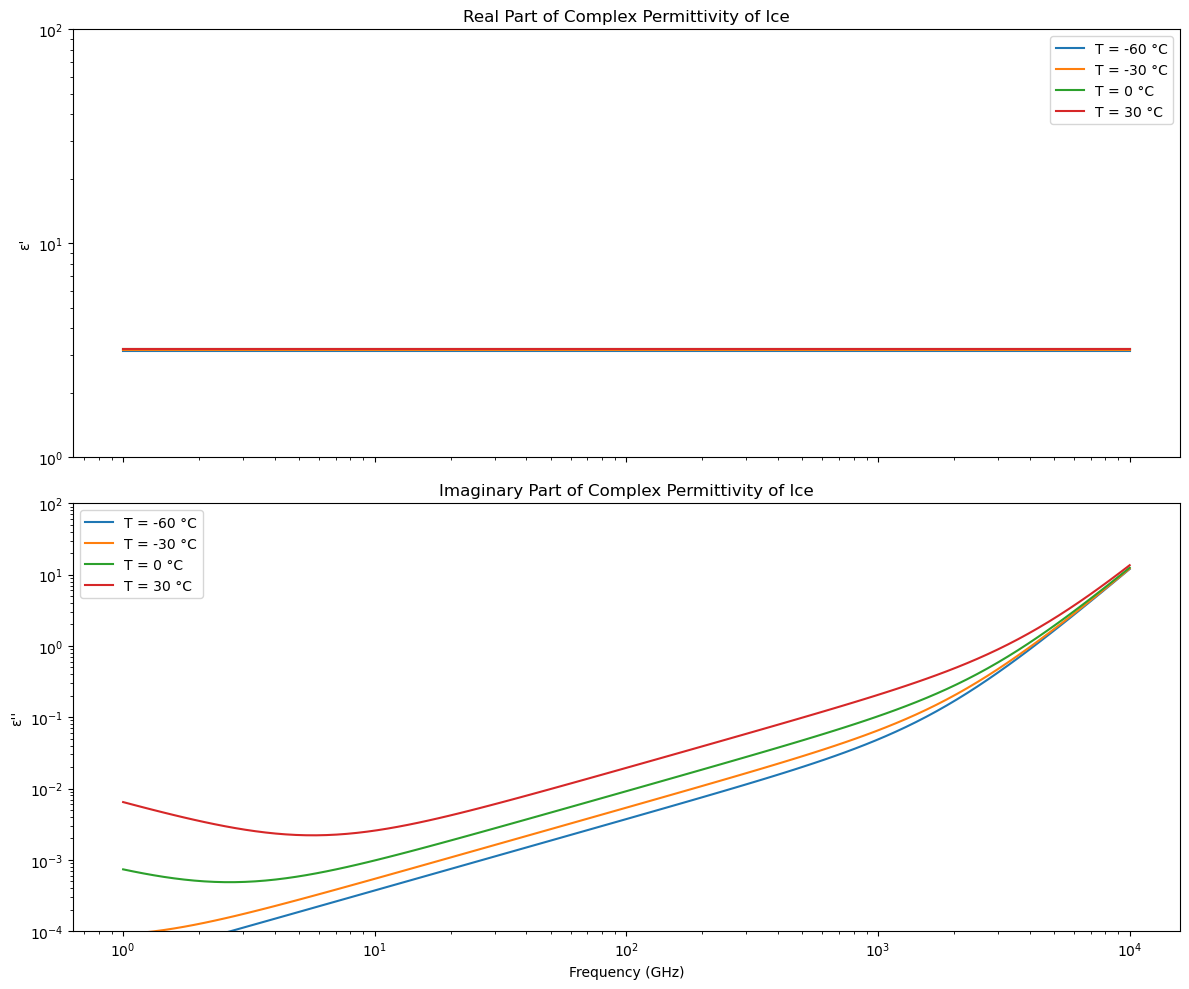

In [3]:
#Let's plot the results in log log scale for both real and imaginary parts in stacked subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axes[0].set_title('Real Part of Complex Permittivity of Ice')
for i, t in enumerate(T):
    axes[0].loglog(nu, epsilon_ice[i].real, label=f'T = {t - 273.15:.0f} °C')
axes[0].set_ylabel("ε'")
axes[0].legend()
axes[0].set_ylim(1e0, 1e2)

axes[1].set_title('Imaginary Part of Complex Permittivity of Ice')
for i, t in enumerate(T):
    axes[1].loglog(nu, epsilon_ice[i].imag, label=f'T = {t - 273.15:.0f} °C')
axes[1].set_xlabel('Frequency (GHz)')
axes[1].set_ylabel("ε''")
axes[1].legend()
axes[1].set_ylim(1e-4, 1e2)

plt.tight_layout()
plt.show()

In [4]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp


LIQUID_WATER_HYBRID_COEFFS = {
    # --- TKC: first two Debye terms ---
    "a1": 8.111e1,
    "b1": 4.434e-3,
    "c1": 1.302e-13,
    "d1": 6.627e2,

    "a2": 2.025e0,
    "b2": 1.073e-2,
    "c2": 1.012e-14,
    "d2": 6.089e2,

    # TKC critical temperature, expressed in Celsius-shift form
    "tc": 1.342e2,

    # --- Ellison 2007: third Debye relaxation ---
    "a3": 1.634967,
    "b3": 0.006841548,
    "c3": 6.30035e-15,
    "d3": 405.5169,

    # --- Ellison 2007: first far-IR resonance ---
    "p0": 0.8379692,
    "p1": -0.006118594,
    "p2": -0.000012936798,

    "p3": 4.235901e12,
    "p4": -1.426088e10,
    "p5": 2.738157e8,
    "p6": -1.246943e6,

    "p7": 9.618642e-14,
    "p8": 1.795786e-16,
    "p9": -9.310017e-18,
    "p10": 1.655473e-19,

    # --- Ellison 2007: second far-IR resonance ---
    "p11": 0.6165532,
    "p12": 0.007238532,
    "p13": -0.00009523366,

    "p14": 1.598317e13,
    "p15": -7.441357e10,
    "p16": 4.97448e8,

    "p17": 2.882476e-14,
    "p18": -3.142118e-16,
    "p19": 3.528051e-18,
}


def kelvin_to_celsius(T_K):
    return jnp.asarray(T_K, dtype=jnp.float64) - 273.15


def eps_static_water_hamelin_from_K(T_K):
    """
    Static dielectric constant of liquid water.

    Input
    -----
    T_K : temperature in Kelvin

    Internally
    ----------
    T_C = T_K - 273.15
    """
    T = kelvin_to_celsius(T_K)

    return (
        87.9144
        - 0.404399 * T
        + 9.58726e-4 * T**2
        - 1.32802e-6 * T**3
    )


@jax.jit
def complex_permittivity_liquid_water_hybrid_K(T_K, freq_GHz):
    """
    Complex permittivity of liquid water.

    Hybrid model:
        - Debye terms 1 and 2 from TKC
        - Debye term 3 from Ellison 2007
        - Far-IR resonances from Ellison 2007

    Inputs
    ------
    freq_GHz : float or array
        Frequency in GHz.

    T_K : float or array
        Temperature in Kelvin.

    Returns
    -------
    epsilon : complex array
        Complex relative permittivity:
            epsilon = epsilon' + i epsilon''
    """
    p = LIQUID_WATER_HYBRID_COEFFS

    nu = jnp.asarray(freq_GHz, dtype=jnp.float64) * 1e9  # GHz -> Hz
    T = kelvin_to_celsius(T_K)                           # K -> °C

    eps_s = eps_static_water_hamelin_from_K(T_K)

    omega = 2.0 * jnp.pi * nu

    # ------------------------------------------------------------
    # Debye amplitudes:
    # Delta_i(T) = a_i exp(-b_i T)
    # with T in Celsius
    # ------------------------------------------------------------
    D1 = p["a1"] * jnp.exp(-p["b1"] * T)
    D2 = p["a2"] * jnp.exp(-p["b2"] * T)
    D3 = p["a3"] * jnp.exp(-p["b3"] * T)

    # ------------------------------------------------------------
    # Debye relaxation times:
    # tau_i(T) = c_i exp(d_i / (T + tc))
    # with T in Celsius
    # ------------------------------------------------------------
    tau1 = p["c1"] * jnp.exp(p["d1"] / (T + p["tc"]))
    tau2 = p["c2"] * jnp.exp(p["d2"] / (T + p["tc"]))
    tau3 = p["c3"] * jnp.exp(p["d3"] / (T + p["tc"]))

    eps_debye = 1j * omega * (
        D1 * tau1 / (1.0 - 1j * omega * tau1)
        + D2 * tau2 / (1.0 - 1j * omega * tau2)
        + D3 * tau3 / (1.0 - 1j * omega * tau3)
    )

    # ------------------------------------------------------------
    # Ellison resonance terms
    # T is still in Celsius
    # ------------------------------------------------------------

    D4 = p["p0"] + p["p1"] * T + p["p2"] * T**2
    f0 = p["p3"] + p["p4"] * T + p["p5"] * T**2 + p["p6"] * T**3
    tau4 = p["p7"] + p["p8"] * T + p["p9"] * T**2 + p["p10"] * T**3

    D5 = p["p11"] + p["p12"] * T + p["p13"] * T**2
    f1 = p["p14"] + p["p15"] * T + p["p16"] * T**2
    tau5 = p["p17"] + p["p18"] * T + p["p19"] * T**2

    eps_res_1 = 1j * jnp.pi * nu * (
        D4 * tau4 / (1.0 - 1j * 2.0 * jnp.pi * tau4 * (f0 + nu))
        + D4 * tau4 / (1.0 + 1j * 2.0 * jnp.pi * tau4 * (f0 - nu))
    )

    eps_res_2 = 1j * jnp.pi * nu * (
        D5 * tau5 / (1.0 - 1j * 2.0 * jnp.pi * tau5 * (f1 + nu))
        + D5 * tau5 / (1.0 + 1j * 2.0 * jnp.pi * tau5 * (f1 - nu))
    )

    return eps_s + eps_debye + eps_res_1 + eps_res_2

In [5]:
epsilon_liquid = jnp.array([complex_permittivity_liquid_water_hybrid_K(t, nu) for t in T])

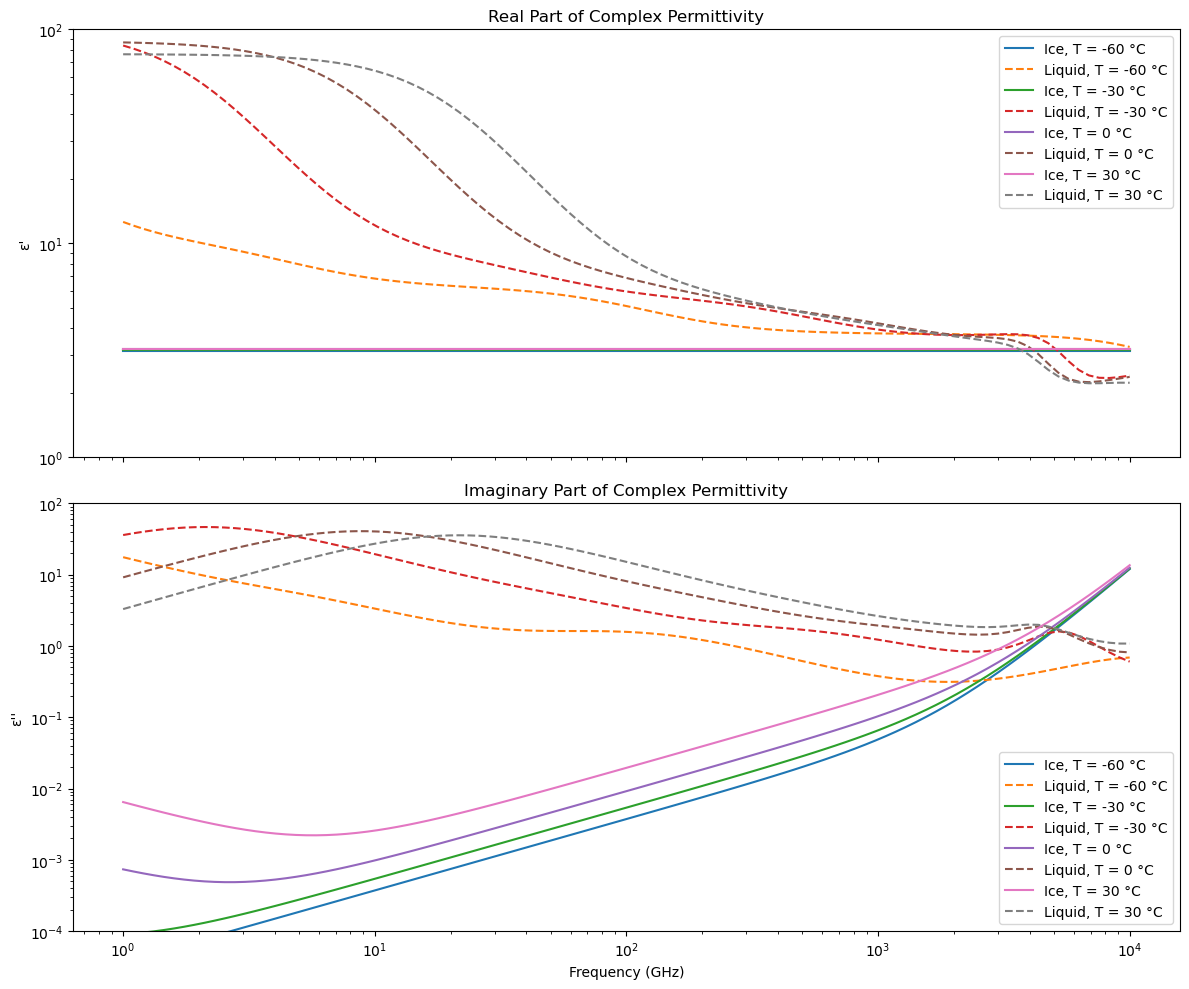

In [6]:
# Compare ice and liquid water on the same stacked plots
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axes[0].set_title('Real Part of Complex Permittivity')
for i, t in enumerate(T):
    axes[0].loglog(nu, epsilon_ice[i].real, label=f'Ice, T = {t - 273.15:.0f} °C')
    axes[0].loglog(nu, epsilon_liquid[i].real, '--', label=f'Liquid, T = {t - 273.15:.0f} °C')
axes[0].set_ylabel("ε'")
axes[0].legend()
axes[0].set_ylim(1e0, 1e2)

axes[1].set_title('Imaginary Part of Complex Permittivity')
for i, t in enumerate(T):
    axes[1].loglog(nu, epsilon_ice[i].imag, label=f'Ice, T = {t - 273.15:.0f} °C')
    axes[1].loglog(nu, epsilon_liquid[i].imag, '--', label=f'Liquid, T = {t - 273.15:.0f} °C')
axes[1].set_xlabel('Frequency (GHz)')
axes[1].set_ylabel("ε''")
axes[1].legend()
axes[1].set_ylim(1e-4, 1e2)

plt.tight_layout()
plt.show()

In [7]:
import atmo3
#from atmo3.ice_emission import complex_permittivity_ice, complex_permittivity_liquid_water_hybrid_K



epsilon_ice_atmo3 = jnp.array([atmo3.ice_emission.complex_permittivity_ice(t, nu) for t in T])

epsilon_liquid_atmo3 = jnp.array([atmo3.ice_emission.complex_permittivity_liquid_water_hybrid_K(t, nu) for t in T])

In [8]:
#Let's compare the results from our implementation and atmo3's implementation for both ice and liquid water
# We'll first plot the difference between the two implementations for ice and liquid water, respectively

diff_ice = epsilon_ice - epsilon_ice_atmo3
diff_liquid = epsilon_liquid - epsilon_liquid_atmo3

# Plot the differences
print(diff_ice)
print(diff_liquid)


[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.